# ConnectTel Customer Churn Prediction

---

## **Problem Statement**

**Business Goal:** ConnectTel is losing revenue due to customer churn. Retaining existing customers costs significantly less than acquiring new ones.  

**Objective:** Build a predictive model to identify customers at high risk of churn so that the retention team can proactively offer incentives (discounts, service upgrades, long-term contracts) to reduce churn.  

**Success Metric:** Increase customer retention, reduce churn rate, and optimize revenue.

---

## **Week 1: Exploratory Data Analysis (EDA) & Feature Engineering**

### **1. Dataset Overview**

The Telco Customer Churn dataset contains:

- **Demographics:** Gender, Senior Citizen, Partner, Dependents  
- **Services:** Phone, Internet (DSL/Fiber), Streaming TV/Movies, Security  
- **Account Info:** Tenure, Contract Type, Payment Method, Monthly Charges, Total Charges  
- **Target Variable:** Churn (Yes/No)

In [14]:
# Load libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# For scaling and encoding
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### **2. Data Cleaning & Preparation**

- Convert `TotalCharges` to numeric  
- Fill missing values  
- Map `Churn` to numeric (Yes → 1, No → 0)

In [15]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values safely (no inplace)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

### **3. Univariate Analysis**

**Figure 1:** Distribution of churn in the dataset

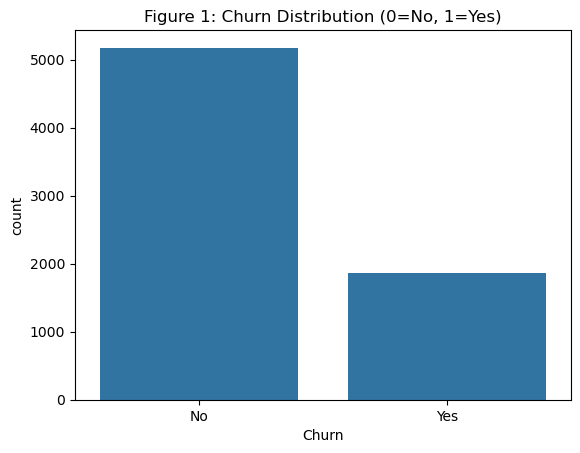

In [16]:
sns.countplot(x='Churn', data=df)
plt.title("Figure 1: Churn Distribution (0=No, 1=Yes)")
plt.show()

**Figure 2:** Churn rate by contract type  
Month-to-Month users tend to churn more than One-Year or Two-Year contracts.

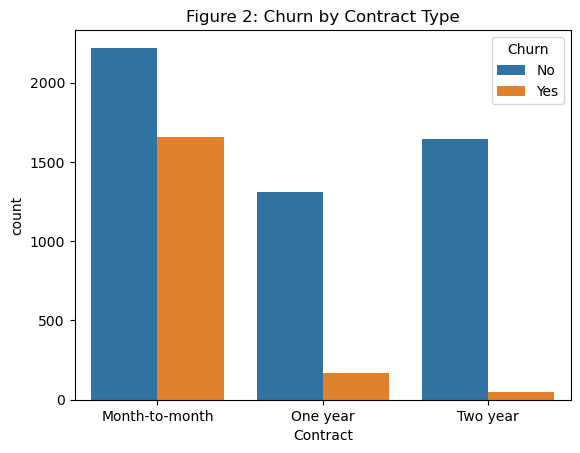

In [17]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Figure 2: Churn by Contract Type")
plt.show()

**Figure 3:** Churn by Internet Service Type  
Fiber Optic users show higher churn compared to DSL users.

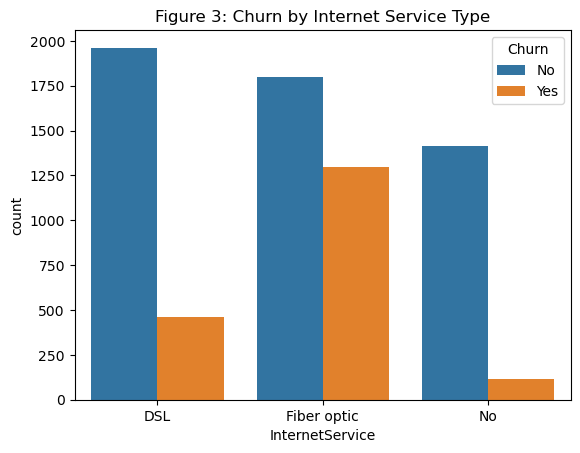

In [18]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Figure 3: Churn by Internet Service Type")
plt.show()

### **4. Multivariate Analysis**

**Figure 4:** Monthly Charges vs Churn  
Higher monthly charges are associated with higher churn.

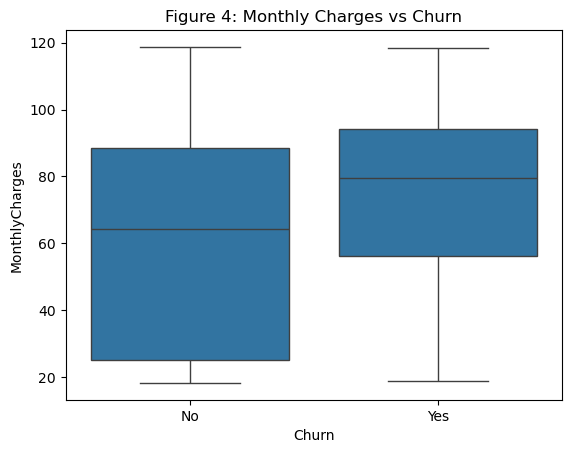

In [19]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Figure 4: Monthly Charges vs Churn")
plt.show()

**Figure 5:** Tenure vs Total Charges  
Customers with longer tenure are less likely to churn.

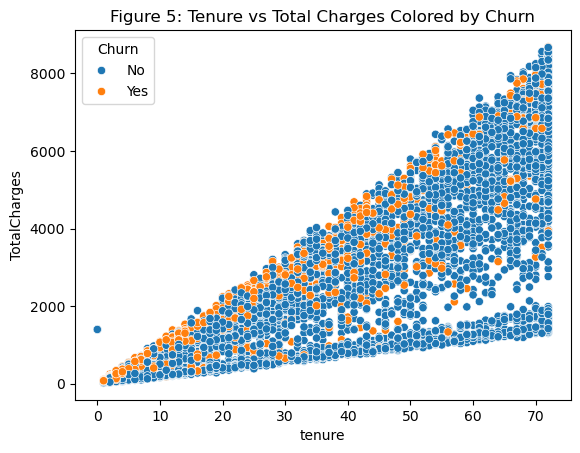

In [20]:
sns.scatterplot(x='tenure', y='TotalCharges', hue='Churn', data=df)
plt.title("Figure 5: Tenure vs Total Charges Colored by Churn")
plt.show()

### **5. Hypothesis Testing**

1. **Fiber Optic customers churn more than DSL users**  
2. **Customers with partners churn less than single customers**

In [23]:
# Convert Churn column from Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Now calculate churn rates safely
fiber_churn = df[df['InternetService']=='Fiber optic']['Churn'].mean()
dsl_churn = df[df['InternetService']=='DSL']['Churn'].mean()
partner_churn = df[df['Partner']=='Yes']['Churn'].mean()
no_partner_churn = df[df['Partner']=='No']['Churn'].mean()

print(f"Fiber Optic Churn Rate: {fiber_churn:.2f}")
print(f"DSL Churn Rate: {dsl_churn:.2f}")
print(f"Partner Churn Rate: {partner_churn:.2f}")
print(f"No Partner Churn Rate: {no_partner_churn:.2f}")

Fiber Optic Churn Rate: 0.42
DSL Churn Rate: 0.19
Partner Churn Rate: 0.20
No Partner Churn Rate: 0.33


### **6. Feature Engineering**

**New Features Created:**

1. **TotalChargesPerTenure** → `TotalCharges / (Tenure + 1)`  
2. **ServiceCount** → Total number of additional services subscribed  
3. **SeniorPartner** → Senior citizen with a partner (binary interaction feature)

In [24]:
df['TotalChargesPerTenure'] = df['TotalCharges'] / (df['tenure'] + 1)

services = ['PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['ServiceCount'] = df[services].apply(lambda x: sum([1 if i=='Yes' else 0 for i in x]), axis=1)

df['SeniorPartner'] = ((df['SeniorCitizen']==1) & (df['Partner']=='Yes')).astype(int)

### **7. Encoding & Scaling**

- One-Hot Encode categorical features  
- Standard Scale numerical features

In [25]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalChargesPerTenure', 'ServiceCount']
scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])

## **8. Key Insights (Week 1)**

- Month-to-Month contracts and Fiber Optic users have higher churn rates.  
- Higher monthly charges increase churn risk.  
- Customers with partners are less likely to churn.  
- Engineered features (`TotalChargesPerTenure`, `ServiceCount`, `SeniorPartner`) will likely improve model performance.

**Next Steps (Week 2):**  
- Split dataset into train/test sets  
- Train baseline models: Logistic Regression & Random Forest  
- Evaluate models using ROC-AUC and confusion matrix

## Week 1 / Phase 1 Summary: Data Preparation & EDA

---

### **Objective**
Understand the Telco Churn dataset, perform exploratory analysis, and engineer features to improve predictive power.

---

### **Key Activities Performed**

#### **1. Data Loading & Cleaning**
- Loaded the dataset and inspected for missing values.  
- Converted `TotalCharges` to numeric and handled missing values safely.  
- Mapped target variable `Churn` from Yes/No → 1/0.  

#### **2. Exploratory Data Analysis (EDA)**
- **Univariate Analysis:** Visualized distributions of `Churn`, `Contract`, `InternetService`, and other categorical features.  
- **Multivariate Analysis:** Explored relationships between numerical features (`MonthlyCharges`, `Tenure`, `TotalCharges`) and churn.  
- **Hypothesis Testing:**  
  - Fiber Optic customers churn more than DSL users.  
  - Customers with partners churn less than those without.  

#### **3. Feature Engineering**
- **TotalChargesPerTenure:** TotalCharges divided by tenure.  
- **ServiceCount:** Number of additional services subscribed.  
- **SeniorPartner:** Binary feature for senior citizens with a partner.  

#### **4. Encoding & Scaling**
- One-Hot Encoding for categorical variables.  
- StandardScaler applied to numerical features.

---

### **Key Insights**
- Month-to-Month contract customers and Fiber Optic internet users are the highest risk groups for churn.  
- Higher monthly charges increase the probability of churn.  
- Customers with partners tend to stay longer.  
- Engineered features (`TotalChargesPerTenure`, `ServiceCount`, `SeniorPartner`) add predictive value for future modeling.

---

### **Next Steps (Week 2)**
- Split the dataset into **train/test sets**.  
- Train baseline models: **Logistic Regression** & **Random Forest**.  
- Evaluate using **ROC-AUC**, **Precision**, and **Recall** metrics.

## **Business Insight (Week 1)**

**Recommendation:**  
"Fiber Optic users with high monthly charges and Month-to-Month contracts are the most likely to churn. Retention strategies should include offering 12-month contract discounts or bundled services to this high-risk group. We recommend offering these customers a 1-year contract discount or bundled services to retain them."  